In [2]:
import os
import tqdm
import pickle
import numpy as np
import networkx as nx
from vbi import report_cfg
import autograd.numpy as anp
import matplotlib.pyplot as plt
from vbi.utils import LoadSample
from vbi.plot import pairplot_numpy
from vbi.models.numba.vep import VEP_sde
from vbi.cde import MAFEstimator, MDNEstimator
from sklearn.preprocessing import StandardScaler
from vbi.utils import posterior_shrinkage_numpy, posterior_zscore_numpy, posterior_peaks_numpy

/beegfs_hdd/data/nfs_share/users/guiyun/nishome/virtualbrain/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
seed = 2
np.random.seed(seed)

In [4]:
weights = np.loadtxt("../data/weights1.txt")
nn = weights.shape[0]

In [5]:
hz_val = -3.65
pz_val = -2.4
ez_val = -1.6

In [6]:
ez_idx = np.array([6, 34], dtype=np.int32)
pz_wplng_idx = np.array([5, 11], dtype=np.int32)
pz_kplng_idx = np.array([27], dtype=np.int32)
pz_idx = np.append(pz_kplng_idx, pz_wplng_idx)

In [7]:
eta_true = np.ones(nn) * hz_val
eta_true[pz_idx] = pz_val
eta_true[ez_idx] = ez_val

In [8]:
initial_state = np.zeros(2 * nn)
initial_state[:nn] = -2.5
initial_state[nn:] = 3.5

In [9]:
params = {
    "G": 1.0,
    "initial_state": initial_state,
    "weights": weights,
    "tau": 5.0,
    "eta": -3.5,
    "sigma": 0.0,
    "iext": 3.1,
    "dt": 0.1,
    "t_end": 14.0,
    "t_cut": 1.0,
    "record_step": 1,
    "method": "heun",
    "output": "../outputs",
}

In [10]:
obj = VEP_sde(params)
g_true = 1.0
eta_true = [-1.6] * 2
eta_true_ = np.ones(nn) * hz_val
eta_true_[pz_idx] = pz_val
eta_true_[ez_idx] = ez_val
control_true = {"eta": eta_true_, "G": g_true}

In [11]:
data = obj.run(par=control_true)

In [ ]:
print(obj.P.eta[:5])
print(obj.P.iext[:5])

[-3.65 -3.65 -3.65 -3.65 -3.65]
[3.1 3.1 3.1 3.1 3.1]


In [12]:
ts = data["x"]
t = data["t"]

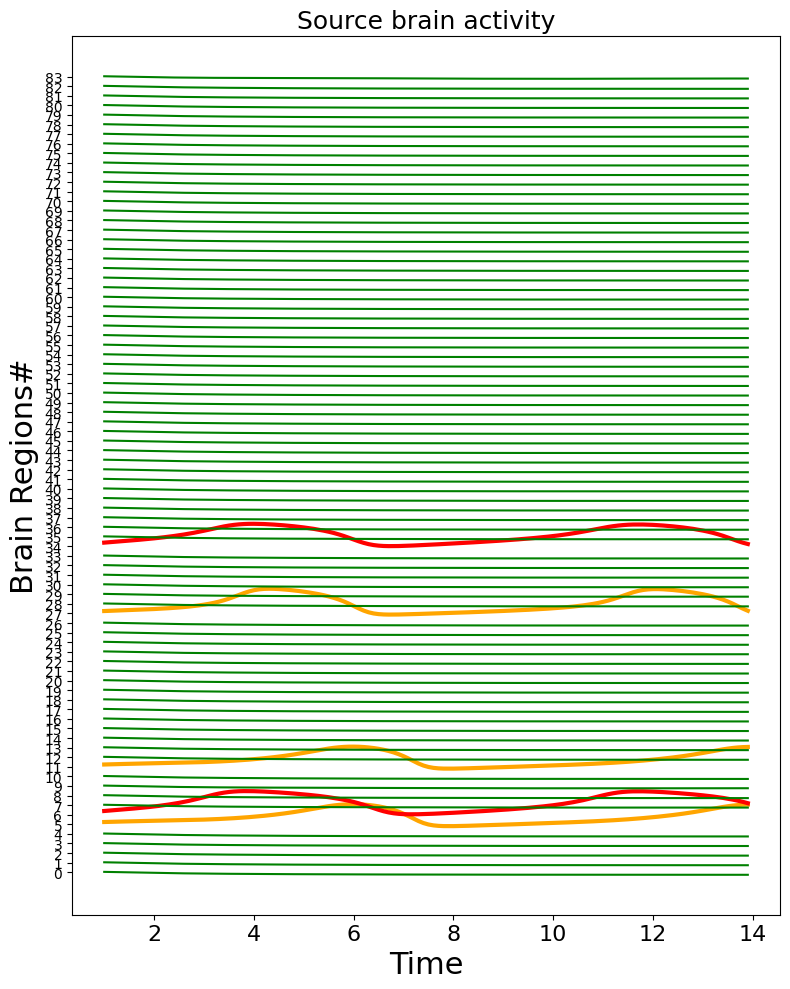

In [13]:

plt.figure(figsize=(8, 10))
for i in range(0, nn):
    if i in ez_idx:
        plt.plot(t, ts[i, :] + i, "r", lw=3)
    elif i in pz_idx:
        plt.plot(t, ts[i, :] + i, "orange", lw=3)
    else:
        plt.plot(t, ts[i, :] + i, "g")
plt.yticks(np.r_[0:nn] - 2, np.r_[0:nn], fontsize=10)
plt.xticks(fontsize=16)
plt.title("Source brain activity", fontsize=18)
plt.xlabel("Time", fontsize=22)
plt.ylabel("Brain Regions#", fontsize=22)
plt.tight_layout()
# plt.savefig("output/vep_sde.png", dpi=300)